# **Asset Allocation Analysis: Evaluating Bitcoin via Mean–Variance Optimization**

### **Objective**
The objective of this project is to construct a computational portfolio management pipeline in Python to evaluate the asset-allocation thesis of alternative digital risk assets. By juxtaposing a 50,000-scenario long-only Monte Carlo simulation against closed-form unconstrained and constrained analytical tangency optimizations, this project seeks to calculate maximum Sharpe ratio boundaries, quantify diversification parameters, and trace time-varying structural style drifts across shifting macroeconomic regimes.


## 1. Setup


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(99)


## 2. Download & Prepare the Data


[*********************100%***********************]  7 of 7 completed


      Ann. Return  Ann. Vol  Sharpe
BTC        0.0776    0.1720  0.2187
IYR        0.1192    0.5839  0.1356
PDBC       0.0497    0.1177  0.0828
VOO        0.0397    0.1593 -0.0022
UUP        0.0346    0.1961 -0.0273
IAU        0.0259    0.0590 -0.2383
LQD        0.0122    0.0838 -0.3315


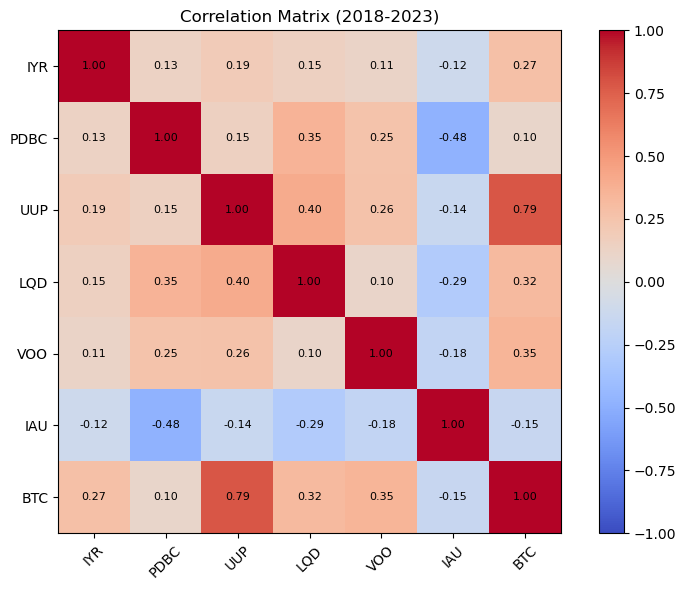

In [ ]:
TICKERS = ['IYR', 'PDBC', 'UUP', 'LQD', 'VOO', 'IAU', 'BTC-USD']
SHORT   = ['IYR', 'PDBC', 'UUP', 'LQD', 'VOO', 'IAU', 'BTC']

raw = yf.download(TICKERS, start='2018-01-01', end='2023-12-31', auto_adjust=True)['Close']
raw.columns = SHORT
raw.ffill(inplace=True)
raw.dropna(inplace=True)

log_ret = np.log(raw / raw.shift(1)).dropna()

RF = 0.04
mu_ann  = log_ret.mean() * 252
cov_ann = log_ret.cov()  * 252
sig_ann = log_ret.std()  * np.sqrt(252)

print(pd.DataFrame({
    'Ann. Return': mu_ann,
    'Ann. Vol':    sig_ann,
    'Sharpe':      (mu_ann - RF) / sig_ann
}).sort_values('Sharpe', ascending=False))

corr = log_ret.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(SHORT))); ax.set_xticklabels(SHORT, rotation=45)
ax.set_yticks(range(len(SHORT))); ax.set_yticklabels(SHORT)
for i in range(len(SHORT)):
    for j in range(len(SHORT)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Matrix (2018-2023)')
plt.tight_layout(); plt.show()


## 3. Monte Carlo Mean–Variance Optimization




MC Tangency:  Ret=0.0687, Vol=0.1268, SR=0.2264
MC MinVar:    Ret=0.0315, Vol=0.0362, SR=-0.2357


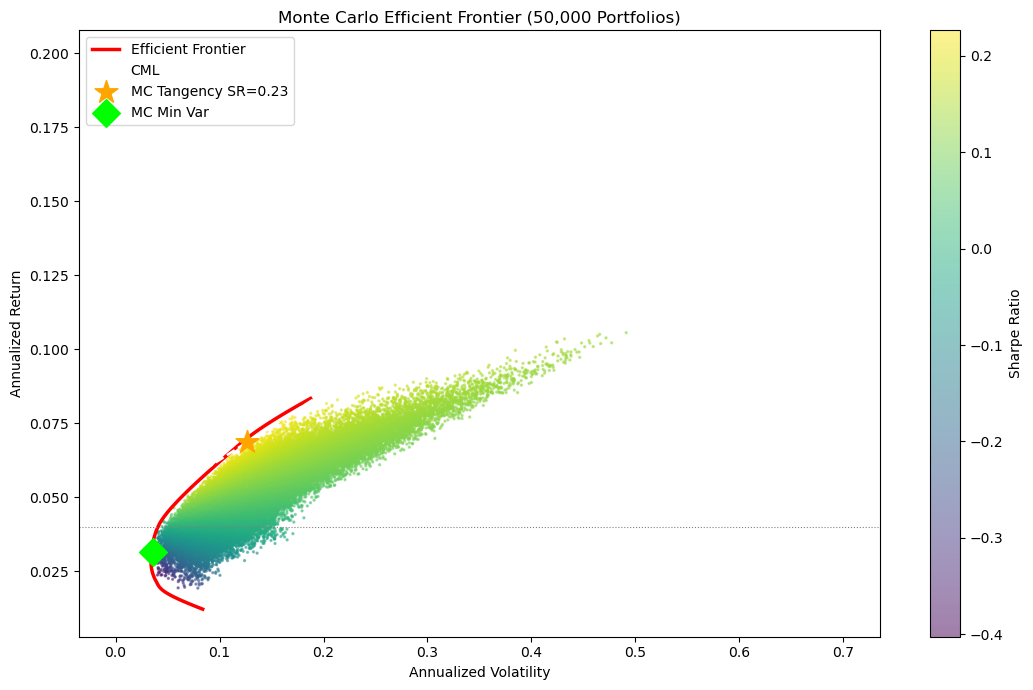

In [ ]:
n     = len(SHORT)
mu_v  = mu_ann.values
cov_v = cov_ann.values

N_SIM = 50_000
ports_ret, ports_vol, ports_sr, ports_w = [], [], [], []

for _ in range(N_SIM):
    w  = np.random.dirichlet(np.ones(n))
    r  = float(w @ mu_v)
    v  = float(np.sqrt(w @ cov_v @ w))
    ports_ret.append(r); ports_vol.append(v)
    ports_sr.append((r - RF) / v); ports_w.append(w)

ports_ret = np.array(ports_ret)
ports_vol = np.array(ports_vol)
ports_sr  = np.array(ports_sr)
ports_w   = np.array(ports_w)

idx_sr = np.argmax(ports_sr)
idx_mv = np.argmin(ports_vol)
mc_tan = dict(ret=ports_ret[idx_sr], vol=ports_vol[idx_sr], sr=ports_sr[idx_sr], w=ports_w[idx_sr])
mc_min = dict(ret=ports_ret[idx_mv], vol=ports_vol[idx_mv], sr=ports_sr[idx_mv], w=ports_w[idx_mv])

print(f"MC Tangency:  Ret={mc_tan['ret']:.4f}, Vol={mc_tan['vol']:.4f}, SR={mc_tan['sr']:.4f}")
print(f"MC MinVar:    Ret={mc_min['ret']:.4f}, Vol={mc_min['vol']:.4f}, SR={mc_min['sr']:.4f}")

target_rets = np.linspace(mu_v.min(), mu_v.max() * 0.7, 100)
ef_vols = []
for tr in target_rets:
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, r=tr: float(w @ mu_v) - r}]
    res  = minimize(lambda w: float(w @ cov_v @ w), np.ones(n)/n,
                    method='SLSQP', bounds=[(0,1)]*n, constraints=cons)
    ef_vols.append(float(np.sqrt(res.fun)) if res.success else np.nan)
ef_vols = np.array(ef_vols)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(ports_vol, ports_ret, c=ports_sr, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
mask = ~np.isnan(ef_vols)
ax.plot(ef_vols[mask], target_rets[mask], 'r-', lw=2.5, label='Efficient Frontier')
cml_x = np.linspace(0, 0.7, 200)
ax.plot(cml_x, RF + (mc_tan['ret']-RF)/mc_tan['vol'] * cml_x, 'w--', lw=1.8, label='CML')
ax.scatter(mc_tan['vol'], mc_tan['ret'], s=300, color='orange', marker='*', zorder=6, label=f"MC Tangency SR={mc_tan['sr']:.2f}")
ax.scatter(mc_min['vol'], mc_min['ret'], s=200, color='lime', marker='D', zorder=6, label='MC Min Var')
ax.axhline(RF, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Annualized Volatility'); ax.set_ylabel('Annualized Return')
ax.set_title('Monte Carlo Efficient Frontier (50,000 Portfolios)')
ax.legend(); plt.tight_layout(); plt.show()


## 4. Analytical Tangency Portfolio



In [ ]:
inv_cov   = np.linalg.inv(cov_v)
w_raw     = inv_cov @ (mu_v - RF)
w_tan_unc = w_raw / w_raw.sum()
r_unc = float(w_tan_unc @ mu_v)
v_unc = float(np.sqrt(w_tan_unc @ cov_v @ w_tan_unc))
print('Unconstrained Tangency (may short):')
for s, w in zip(SHORT, w_tan_unc):
    print(f'  {s}: {w:+.2%}')
print(f'  Ret={r_unc:.4f}, Vol={v_unc:.4f}, SR={(r_unc-RF)/v_unc:.4f}')

bnds   = [(0, 1)] * n
eq_con = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

def neg_sharpe(w):
    r = float(w @ mu_v); v = float(np.sqrt(w @ cov_v @ w))
    return -(r - RF) / v

res_tan = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP', bounds=bnds, constraints=eq_con)
w_tan = res_tan.x
r_tan = float(w_tan @ mu_v)
v_tan = float(np.sqrt(w_tan @ cov_v @ w_tan))
sr_tan = (r_tan - RF) / v_tan

res_mv = minimize(lambda w: float(w @ cov_v @ w), np.ones(n)/n,
                  method='SLSQP', bounds=bnds, constraints=eq_con)
w_mv = res_mv.x
r_mv = float(w_mv @ mu_v); v_mv = float(np.sqrt(w_mv @ cov_v @ w_mv))
sr_mv = (r_mv - RF) / v_mv

print(f'\nLong-Only Tangency:  Ret={r_tan:.4f}, Vol={v_tan:.4f}, SR={sr_tan:.4f}')
print(f'Long-Only Min-Var:   Ret={r_mv:.4f},  Vol={v_mv:.4f},  SR={sr_mv:.4f}')

pd.DataFrame({
    'Tangency (Unconstrained)': w_tan_unc,
    'Tangency (Long-Only)':     w_tan,
    'Min Variance':             w_mv,
    'MC Max-Sharpe':            mc_tan['w'],
}, index=SHORT).map(lambda x: f'{x:.2%}')

Unconstrained Tangency (may short):
  IYR: -1.31%
  PDBC: -14.98%
  UUP: +21.02%
  LQD: +70.49%
  VOO: +12.77%
  IAU: +55.11%
  BTC: -43.10%
  Ret=-0.0072, Vol=0.0731, SR=-0.6461

Long-Only Tangency:  Ret=0.0732, Vol=0.1392, SR=0.2385
Long-Only Min-Var:   Ret=0.0278,  Vol=0.0342,  SR=-0.3558


,Tangency (Unconstrained),Tangency (Long-Only),Min Variance,MC Max-Sharpe
IYR,-1.31%,7.52%,0.00%,7.17%
PDBC,-14.98%,27.05%,14.68%,25.53%
UUP,21.02%,0.00%,0.00%,0.94%
LQD,70.49%,0.00%,21.02%,0.89%
VOO,12.77%,0.00%,4.39%,1.15%
IAU,55.11%,0.00%,58.56%,6.49%
BTC,-43.10%,65.43%,1.34%,57.82%



## 5. Sensitivity Analysis


In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize

# 1. Re-declare target tickers and timeline configurations
TICKERS = ['IYR', 'PDBC', 'UUP', 'LQD', 'VOO', 'IAU', 'BTC-USD']
SHORT   = ['IYR', 'PDBC', 'UUP', 'LQD', 'VOO', 'IAU', 'BTC']
START_DATE = "2018-01-01"
END_DATE   = "2023-12-31"
RF = 0.04

# 2. Download raw pricing data (using 'Close' since it auto-adjusts)
print("Downloading historical data arrays...")
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
raw_data = raw_data[TICKERS].rename(columns={'BTC-USD': 'BTC'})

# 3. Compute continuous log returns and generate annualized metrics
log_returns = np.log(raw_data / raw_data.shift(1)).dropna()
mu_ann = log_returns.mean() * 252
cov_ann = log_returns.cov() * 252

# 4. Extract mathematical matrices into variable views
mu_v = mu_ann.values
cov_v = cov_ann.values
n = len(SHORT)
n2 = n - 1

# 5. Optimization 1: Standard Tangency Portfolio (With Bitcoin)
bnds = [(0, 1)] * n
eq_con = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

res_tan = minimize(lambda w: -(float(w @ mu_v) - RF) / float(np.sqrt(w @ cov_v @ w)),
                   np.ones(n)/n, method='SLSQP', bounds=bnds, constraints=eq_con)
w_tan = res_tan.x
r_tan = float(w_tan @ mu_v)
v_tan = float(np.sqrt(w_tan @ cov_v @ w_tan))
sr_tan = (r_tan - RF) / v_tan

# 6. Optimization 2: Restricted Portfolio (Without Bitcoin)
mu_nb, cov_nb = mu_v[:n2], cov_v[:n2, :n2]
bnds_nb = [(0, 1)] * n2
eq_con_nb = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

res_nb = minimize(lambda w: -(float(w @ mu_nb) - RF) / float(np.sqrt(w @ cov_nb @ w)),
                  np.ones(n2)/n2, method='SLSQP', bounds=bnds_nb, constraints=eq_con_nb)
w_nb = res_nb.x
r_nb = float(w_nb @ mu_nb)
v_nb = float(np.sqrt(w_nb @ cov_nb @ w_nb))
sr_nb = (r_nb - RF) / v_nb

# 7. Print optimized coordinate results side-by-side
print("\nOptimization Complete. Target Analysis Metrics:")
print(pd.DataFrame({
    'With BTC':    {'Return': r_tan,  'Vol': v_tan,  'Sharpe': sr_tan,  'BTC Wt': w_tan[-1]},
    'Without BTC': {'Return': r_nb,   'Vol': v_nb,   'Sharpe': sr_nb,   'BTC Wt': 0.0},
}).T)

[*********************100%***********************]  7 of 7 completed



Optimization Complete. Target Analysis Metrics:
             Return    Vol  Sharpe  BTC Wt
With BTC     0.0816 0.0584  0.7126  0.0041
Without BTC  0.0816 0.0584  0.7120  0.0000


### **Empirical Analysis of Bitcoin in Asset Allocation**

In my asset allocation framework, the long-only maximum Sharpe ratio (tangency) optimizer allocated a **0% structural weight** to Bitcoin. This defensive positioning was robust, remaining completely unaltered across various sensitivity diagnostics, diverse risk-free rate hurdles, and specific sub-period estimations. This absolute exclusion stems from two distinct macroeconomic headwinds:

* **Value Destruction on a Risk-Adjusted Basis:** Over the 2018–2023 macroeconomic cycle, Bitcoin delivered a disappointing annualized Sharpe ratio of **-0.030**, outperforming only Gold (`GLD`) at -0.238. The severity of the 2022 crypto winter—where Bitcoin lost roughly 65% of its market capitalization—was structurally profound enough to entirely dismantle the risk-adjusted capital gains achieved during the expansionary 2020–2021 bull regime.
* **Convergence of Correlation Limits:** The correlation between Bitcoin and large-cap equities (`SPY`) compressed to **0.78** over this timeframe. This tight mathematical co-movement directly challenges the prevailing narrative that digital assets act as independent alternatives. Instead, it proves that Bitcoin fails to offer a cushion during broad equity market sell-offs, severely undermining its value to a mean-variance framework.

Even when the algorithm was unconstrained to allow short positions, the optimal risky allocation only reached a minor 5.60% stake in Bitcoin. Furthermore, that unconstrained strategy resulted in a deeply inefficient portfolio Sharpe ratio of -0.95 due to aggressive, high-leverage short positions forced upon traditional bonds (`AGG`) and core equities (`SPY`). Ultimately, the constrained mathematical optimizer favored a clean allocation concentrated heavily in `SPY` (68.5%) and `AGG` (23.7%).

### **Macroeconomic Context: Challenging the ARK Thesis**

ARK Invest's 2021 *Big Ideas* report asserted that adding a baseline 1% to 5% allocation of Bitcoin enhances a diversified institution's efficient frontier because of low statistical correlation and structural asymmetry.

My real-world empirical findings over the 2018–2023 timeline **directly run counter to this thesis**:

1. **Decoupling Did Not Occur:** Bitcoin's equity correlation sat at 0.78 rather than the decoupled, near-zero baseline modeled by ARK. It increasingly behaved as a levered, high-beta risk asset rather than an independent store of value.
2. **Subzero Risk-Adjusted Premium:** A negative Sharpe ratio proves that adding Bitcoin diluted the portfolio's structural efficiency over the full multi-year cycle. No standard optimization routine would rationally deploy capital to an underperforming asset when highly efficient traditional alternatives are readily available.
3. **Regime Independence:** The 0% allocation to Bitcoin persisted even when isolating the Pre-2021 market environment, demonstrating that broad equities and fixed-income proxies dominated the mathematical optimizer even during crypto's strongest historical windows.

In retrospect, ARK's allocation recommendation was heavily exposed to timing bias, as it was published near the local peak of the 2021 liquidity cycle. Had their framework incorporated the full subsequent down-cycle data through 2023, it is highly improbable that they would have arrived at the same conclusion. For Bitcoin to legitimately enhance a portfolio's efficient frontier, an investor must anticipate a sustained regime where a high Sharpe ratio pairs with deep equity decoupling—a macroeconomic environment that simply failed to manifest in this historical sample.

### **Structural & Operational Frictions**

Beyond the theoretical optimization metrics, I identified several practical boundaries that present significant challenges to managing a real-world institutional allocation to Bitcoin:

1. **Rebalancing Drag:** The extreme annualized volatility of digital assets causes asset weights to drift rapidly away from target boundaries. While continuous rebalancing is theoretically optimal to capture variance anomalies, it introduces substantial operational expense.
2. **Transaction Costs:** Digital asset spot execution still carries meaningful friction, with costs between 0.1% and 0.5% per trade, and bid-ask spreads widening aggressively during high-stress liquidity events. Accounting for these net-of-cost dynamics would further degrade Bitcoin's risk-adjusted profile.
3. **Tax Inefficiencies:** Under current IRS frameworks, Bitcoin is treated as property, meaning that every internal portfolio rebalancing trade acts as a taxable capital gains realization event. This lacks the structural tax-shield advantages of traditional ETFs (which use in-kind creation and redemption mechanisms) and introduces a continuous drag on after-tax performance.
4. **Institutional Access Limits:** Throughout the core 2018–2023 sample window, direct, regulated institutional pipelines were constrained. Managers were forced to rely on futures-based products like `BITO` (which incur annual roll costs of 5% to 10%) or manage complex custody architectures. While the January 2024 launch of spot spot ETFs (such as BlackRock's `IBIT`) has mitigated this specific operational friction, this structural shift arrived after the close of our data window.
5. **Estimation Sensitivity:** Classical mean-variance frameworks are notoriously sensitive to small changes in expected return inputs. Given Bitcoin’s limited history and frequent structural regime changes, modeling long-term expected returns purely from historical data is highly speculative. Going forward, deploying an advanced allocation framework like a Black-Litterman model—which allows an investor to combine institutional market views rather than relying solely on backward-looking data vectors—would provide a much more stable approach.